# Agenda:
1. Data Understanding
- Quanitative
   - Discrete
   - Continous
- Qualitative
  - Nominal
  - Ordinal
2. Data Sampling
  - Random
  - Systematic
  - Stratified
  - Cluster
  - Biased
3. Visualization for differenet Data -  Distribution
  - Histograms
  - Countplot
  - Boxplot
  - Pie Chart
  - KDE plot
  - Line Plot
  - Violin Plot
4. Univariate Analysis as per chartz for understanding patterns
5. Summarization

# Step 0 : Data Ingestion

In [2]:
# step 0 : library importing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# import seaborn Data set List()
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [4]:
df = sns.load_dataset('taxis')
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


# Step 1 - Data Understanding

In [5]:
# information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

### Observations from `df.info()`:
- The dataset contains 6433 entries and 14 columns.
- Data types include datetime, numerical (float and int), and categorical (object) columns.
- There are missing values in several columns, including `payment`, `pickup_zone`, `dropoff_zone`, and `dropoff_borough`.

In [6]:
# Descriptive Stats
df.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


### Observations from `df.describe()`:

1.  **Completeness**: All numerical columns (`passengers`, `distance`, `fare`, `tip`, `tolls`, `total`) have 6433 non-null entries, indicating that there are no missing values in these columns.
2.  **`passengers`**:
    *   The mean number of passengers is approximately **1.54**.
    *   The minimum value is **0**, which could represent empty taxis or cancelled rides, warranting further investigation.
    *   The maximum value is **6**.
    *   The 25th, 50th (median), and 75th percentiles are 1, 1, and 2 respectively, suggesting that the majority of trips involve 1 or 2 passengers.
3.  **`distance`**:
    *   The average distance traveled is around **3.02 miles**.
    *   There's a significant spread, with a standard deviation of **3.83 miles**, indicating a wide range of trip distances.
    *   The minimum distance is **0 miles**, similar to passengers, this could indicate cancelled trips or very short movements.
    *   The maximum distance is **36.7 miles**, suggesting some long-distance trips.
4.  **`fare`**:
    *   The average fare is about **$13.09**.
    *   Fares range from a minimum of **$1.00** to a maximum of **$150.00**, showing a broad spectrum of trip costs.
    *   The standard deviation of **$11.55** highlights the variability in fare prices.
5.  **`tip`**:
    *   The average tip is approximately **$1.98**.
    *   Notably, the 25th percentile is **$0.00**, indicating that at least 25% of rides did not receive a tip.
    *   The maximum tip recorded is **$33.20**, showing some generous tipping.
6.  **`tolls`**:
    *   The average tolls are very low at **$0.33**.
    *   The 25th, 50th, and 75th percentiles are all **$0.00**, meaning that the vast majority of rides did not incur any tolls.
    *   The maximum toll is **$24.02**.
7.  **`total`**:
    *   The average total cost (fare + tip + tolls) is around **$18.52**.
    *   Total costs range from **$1.30** to **$174.82**, reflecting the combined variability of fares, tips, and tolls.

In [7]:
### categorial data -statistics
df.describe(include='object')

,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
count,6433,6389,6407,6388,6407,6388
unique,2,2,194,203,4,5
top,yellow,credit card,Midtown Center,Upper East Side North,Manhattan,Manhattan
freq,5451,4577,230,245,5268,5206


### Observations from `df.describe(include='object')`:

1.  **`color`**:
    *   There are **2 unique colors**, with 'yellow' being the predominant color, appearing **5451 times** out of 6433 entries.
    *   No missing values.
2.  **`payment`**:
    *   There are **2 unique payment methods**.
    *   'credit card' is the most frequent payment method, used **4577 times**.
    *   There are **44 missing values** (6433 total - 6389 non-null).
3.  **`pickup_zone`**:
    *   There are **194 unique pickup zones**.
    *   'Midtown Center' is the most frequent pickup zone, appearing **230 times**.
    *   There are **26 missing values** (6433 total - 6407 non-null).
4.  **`dropoff_zone`**:
    *   There are **203 unique dropoff zones**.
    *   'Upper East Side North' is the most frequent dropoff zone, appearing **245 times**.
    *   There are **45 missing values** (6433 total - 6388 non-null).
5.  **`pickup_borough`**:
    *   There are **4 unique pickup boroughs**.
    *   'Manhattan' is by far the most frequent pickup borough, accounting for **5268 entries**.
    *   There are **26 missing values** (6433 total - 6407 non-null).
6.  **`dropoff_borough`**:
    *   There are **5 unique dropoff boroughs**.
    *   'Manhattan' is also the most frequent dropoff borough, with **5206 entries**.
    *   There are **45 missing values** (6433 total - 6388 non-null).

##Step 2: Sampling of Data - Experiment

In [8]:
# random sampling

df_random_sample = df.sample(20)
df_random_sample.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
513,2019-03-19 15:20:37,2019-03-19 15:35:12,1,2.00,11.5,1.48,0.0,16.28,yellow,credit card,Lenox Hill West,Upper West Side North,Manhattan,Manhattan
388,2019-03-19 23:23:12,2019-03-19 23:38:38,1,3.37,13.5,2.00,0.0,19.30,yellow,credit card,Clinton East,Alphabet City,Manhattan,Manhattan
3408,2019-03-04 19:20:29,2019-03-04 19:23:30,1,0.50,4.0,1.25,0.0,9.55,yellow,credit card,Union Sq,Gramercy,Manhattan,Manhattan
3401,2019-03-05 22:10:58,2019-03-05 22:21:05,1,2.35,9.5,3.32,0.0,16.62,yellow,credit card,Murray Hill,Upper East Side North,Manhattan,Manhattan
2264,2019-03-23 15:38:12,2019-03-23 15:48:10,1,0.86,7.5,2.16,0.0,12.96,yellow,credit card,Union Sq,West Village,Manhattan,Manhattan


In [9]:
# systematic sampling
df_systematic_sample = df.iloc[:3:20:100]
df_systematic_sample.head()

SyntaxError: invalid syntax (3763385923.py, line 2)

In [10]:
# stratified sample
df_strata_sample = df.groupby('payment').apply(lambda x: x.sample(min(len(x), 20)))
df_strata_sample

/tmp/ipykernel_3490/1444234677.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_strata_sample = df.groupby('payment').apply(lambda x: x.sample(min(len(x), 20)))


pickup             dropoff  passengers  \
payment                                                                
cash        6368 2019-03-05 18:55:59 2019-03-05 19:03:09           2   
            586  2019-03-14 08:56:08 2019-03-14 09:23:15           1   
            741  2019-03-05 22:19:04 2019-03-05 22:25:14           2   
            3213 2019-03-14 09:27:03 2019-03-14 09:35:12           1   
            3718 2019-03-25 12:20:49 2019-03-25 12:42:46           1   
            4050 2019-03-13 14:05:19 2019-03-13 15:01:16           6   
            4046 2019-03-08 20:49:42 2019-03-08 20:54:55           1   
            843  2019-03-23 07:01:18 2019-03-23 07:04:47           6   
            4030 2019-03-18 14:28:51 2019-03-18 14:33:16           1   
            1194 2019-03-09 11:44:01 2019-03-09 11:54:18           1   
            460  2019-03-22 18:00:02 2019-03-22 18:13:31           1   
            305  2019-03-13 11:29:40 2019-03-13 11:39:38           2   
            5194 2019-03-26 03:16:36 2019-03-26 03:35:04           1   
            5678 2019-03-15 20:34:02 2019-03-15 20:34:10           1   
            3932 2019-03-28 18:55:11 2019-03-28 19:30:04           2   
            5758 2019-03-30 09:25:32 2019-03-30 09:54:33           1   
            2050 2019-03-11 06:56:16 2019-03-11 07:05:39           2   
            4297 2019-03-12 15:28:40 2019-03-12 15:42:46           1   
            4686 2019-03-22 20:15:23 2019-03-22 20:22:57           1   
            5474 2019-03-15 13:07:37 2019-03-15 13:12:41           1   
credit card 3112 2019-03-26 20:20:25 2019-03-26 20:24:43           1   
            2605 2019-03-23 21:54:35 2019-03-23 22:05:40           1   
            3049 2019-03-20 08:15:02 2019-03-20 08:38:08           1   
            2256 2019-03-08 19:39:58 2019-03-08 20:09:19           0   
            6152 2019-03-27 11:27:02 2019-03-27 12:14:22           1   
            4388 2019-03-02 17:29:24 2019-03-02 17:35:57           1   
            5584 2019-03-05 14:18:39 2019-03-05 14:30:34           2   
            2953 2019-03-12 08:51:14 2019-03-12 08:56:02           1   
            1151 2019-03-16 20:13:27 2019-03-16 20:24:59           1   
            2259 2019-03-04 12:36:56 2019-03-04 12:39:16           1   
            1429 2019-03-26 13:01:46 2019-03-26 13:12:59           1   
            1337 2019-03-31 12:10:57 2019-03-31 12:21:44           1   
            5587 2019-03-18 06:31:55 2019-03-18 06:54:01           1   
            5757 2019-03-13 15:39:47 2019-03-13 15:51:00           1   
            2613 2019-03-08 21:13:45 2019-03-08 22:05:02           2   
            6096 2019-03-06 23:32:50 2019-03-06 23:34:31           1   
            2878 2019-03-17 06:30:33 2019-03-17 06:34:07           1   
            4071 2019-03-18 02:34:32 2019-03-18 02:42:41           1   
            229  2019-03-19 23:32:01 2019-03-19 23:40:05           1   
            5296 2019-03-22 10:59:23 2019-03-22 11:21:35           3   

                  distance    fare   tip  tolls   total   color      payment  \
payment                                                                        
cash        6368      1.05    6.50  0.00   0.00    8.30   green         cash   
            586       3.20   18.50  0.00   0.00   21.80  yellow         cash   
            741       0.92    6.00  0.00   0.00    9.80  yellow         cash   
            3213      1.25    7.50  0.00   0.00   10.80  yellow         cash   
            3718      8.47   26.50  0.00   0.00   29.80  yellow         cash   
            4050     33.76  143.50  0.00   0.00  144.30  yellow         cash   
            4046      1.10    6.00  0.00   0.00    9.80  yellow         cash   
            843       1.04    5.00  0.00   0.00    8.30  yellow         cash   
            4030      0.70    5.00  0.00   0.00    8.30  yellow         cash   
            1194      1.96    9.00  0.00   0.00   12.30  yellow         cash   
            460       1.80   10.00  0.00   0.

In [11]:
df_strata_sample.tail()

pickup             dropoff  passengers  \
payment                                                                
credit card 6096 2019-03-06 23:32:50 2019-03-06 23:34:31           1   
            2878 2019-03-17 06:30:33 2019-03-17 06:34:07           1   
            4071 2019-03-18 02:34:32 2019-03-18 02:42:41           1   
            229  2019-03-19 23:32:01 2019-03-19 23:40:05           1   
            5296 2019-03-22 10:59:23 2019-03-22 11:21:35           3   

                  distance  fare   tip  tolls  total   color      payment  \
payment                                                                     
credit card 6096      0.30   3.5  2.50    0.0   7.30   green  credit card   
            2878      0.55   4.5  1.20    0.0   9.00  yellow  credit card   
            4071      2.96  10.0  4.14    0.0  17.94  yellow  credit card   
            229       1.86   8.0  2.36    0.0  14.16  yellow  credit card   
            5296      3.48  16.0  1.50    0.0  20.80  yellow  credit card   

                                pickup_zone           dropoff_zone  \
payment                                                              
credit card 6096                    Astoria                Astoria   
            2878  Times Sq/Theatre District         Midtown Center   
            4071                   Gramercy         Yorkville West   
            229   Times Sq/Theatre District               Union Sq   
            5296              Midtown South  Upper West Side South   

                 pickup_borough dropoff_borough  
payment                                          
credit card 6096         Queens          Queens  
            2878      Manhattan       Manhattan  
            4071      Manhattan       Manhattan  
            229       Manhattan       Manhattan  
            5296      Manhattan       Manhattan

In [12]:
# cluster_sampling
df_cluster_sample = df.iloc[::100]
df_cluster_sample.head()


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
100,2019-03-28 11:28:29,2019-03-28 11:49:30,1,1.79,13.5,3.36,0.0,20.16,yellow,credit card,Lincoln Square East,Midtown South,Manhattan,Manhattan
200,2019-03-14 07:59:57,2019-03-14 08:09:42,1,1.40,8.5,2.35,0.0,14.15,yellow,credit card,Upper East Side South,Upper East Side North,Manhattan,Manhattan
300,2019-03-15 02:02:17,2019-03-15 02:16:41,2,8.02,23.0,0.00,0.0,24.30,yellow,cash,Steinway,Hillcrest/Pomonok,Queens,Queens
400,2019-03-09 17:26:02,2019-03-09 17:26:10,1,0.90,2.5,0.00,0.0,5.80,yellow,cash,Murray Hill,Murray Hill,Manhattan,Manhattan


In [13]:
# biased_sampling
df_biased_sample = df[df['payment'] == 'credit card']
df_biased_sample.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
5,2019-03-11 10:37:23,2019-03-11 10:47:31,1,0.49,7.5,2.16,0.0,12.96,yellow,credit card,Times Sq/Theatre District,Midtown East,Manhattan,Manhattan


### Step 3 :Data cleaning

In [14]:
## Missing data analysis
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


### Filling the all null value :

In [15]:
# for all missing data lets fill them with mode() of that respective column, save the details
df.payment.fillna(df.payment.mode()[0], inplace=True)
df.pickup_zone.fillna(df.pickup_zone.mode()[0], inplace=True)
df.dropoff_zone.fillna(df.dropoff_zone.mode()[0], inplace=True)
df.pickup_borough.fillna(df.pickup_borough.mode()[0], inplace=True)
df.dropoff_borough.fillna(df.dropoff_borough.mode()[0], inplace=True)

/tmp/ipykernel_3490/2423371223.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.payment.fillna(df.payment.mode()[0], inplace=True)
/tmp/ipykernel_3490/2423371223.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [16]:
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0


## 3 Visualization Choices for Data Distribution :

To effectively visualize the distribution of each column in our df DataFrame, we will select appropriate plotting techniques based on their data types and characteristics:

passengers (Discrete Numerical):

Countplot: Ideal for showing the frequency of each discrete passenger count.
Histogram: Can also be used to visualize the distribution of passenger counts, treating them as bins.
distance, fare, tip, tolls, total (Continuous Numerical):

Histograms & KDE plots: To understand the shape, central tendency, and spread of these continuous distributions. KDE (Kernel Density Estimate) provides a smoothed version of the histogram, showing the probability density.
Boxplots & Violin plots: Excellent for visualizing the five-number summary (minimum, first quartile, median, third quartile, maximum) and identifying outliers, and for violin plots, the density of the distribution.
color, payment (Categorical - few unique values):

Countplot: Best for showing the frequency of each category (e.g., how many 'yellow' vs. 'green' taxis, or 'credit card' vs. 'cash' payments).
Pie Chart: Can be used for a quick visual of proportions, especially given the small number of unique categories.
pickup_zone, dropoff_zone, pickup_borough, dropoff_borough (Categorical - varying unique values):

Countplot: Most suitable for showing the frequency of the top occurring zones or boroughs. Due to the high number of unique zones, a pie chart would be impractical.
pickup, dropoff (Datetime):

These columns represent timestamps. For distribution analysis, we might extract components like hour of day, day of week, or month, and then use Histograms or Countplots on these extracted numerical/categorical features. A Line Plot could be used to show trends in pickups/dropoffs over the time range of the dataset.

#### Passenger Analysis

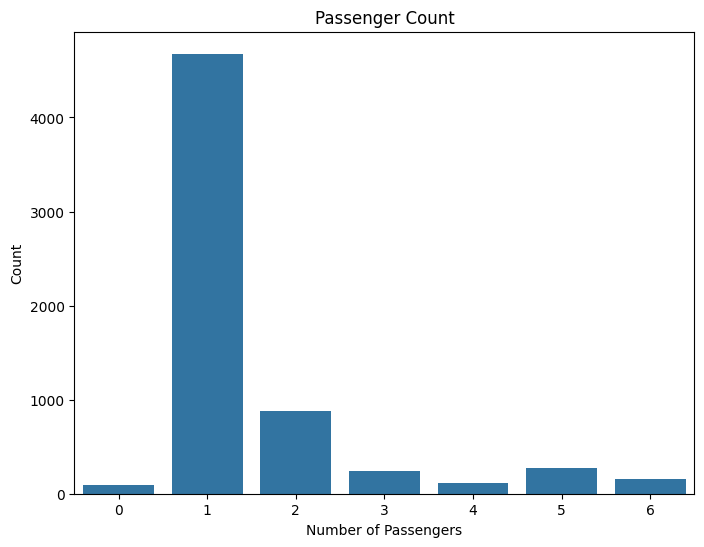

In [17]:
# countplot
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='passengers')
plt.title('Passenger Count')
plt.xlabel('Number of Passengers')
plt.ylabel('Count')
plt.show()



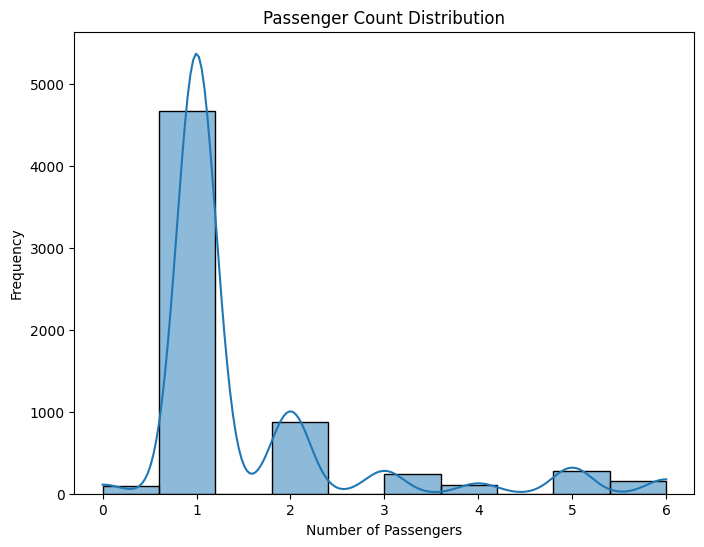

In [18]:
# histogram
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='passengers', bins=10, kde=True)
plt.title('Passenger Count Distribution')
plt.xlabel('Number of Passengers')
plt.ylabel('Frequency')
plt.show()

### Observations from the Passenger Count Histogram:

1.  **Dominant Category**: The most frequent number of passengers per trip is 1, indicating that the majority of rides are taken by a single person.
2.  **Second Most Frequent**: Trips with 2 passengers are also quite common, though less frequent than single-passenger trips.
3.  **Decreasing Frequency**: The frequency of trips rapidly decreases as the number of passengers increases beyond 2. Trips with 3, 4, 5, and 6 passengers are progressively less common.
4.  **Minimum Passengers**: The histogram (and descriptive statistics) show that there are trips with 0 passengers. This could indicate instances of canceled rides or taxis driving without passengers, which might warrant further investigation to understand its nature.
5.  **Distribution Shape**: The distribution is heavily skewed to the right, with a long tail towards higher passenger counts, confirming that higher passenger numbers are rare.

## Fare Analysis :-

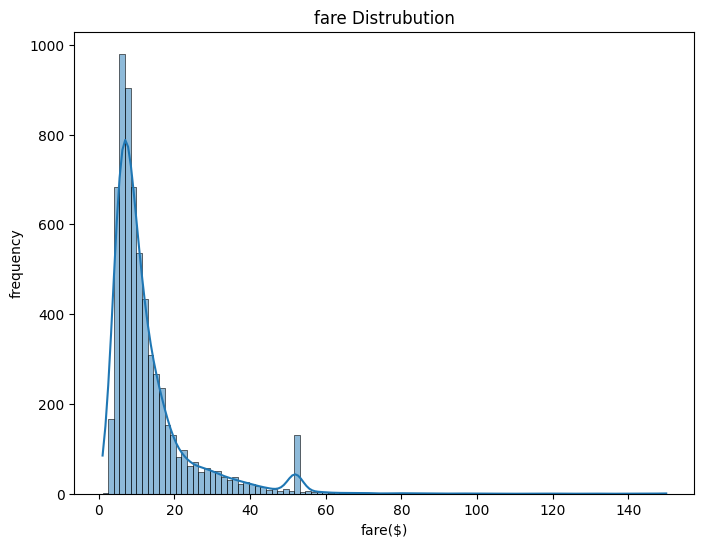

In [19]:
# histogram
plt.figure(figsize=(8, 6))
sns.histplot(data=df,x='fare',bins=100, kde=True)
plt.title('fare Distrubution')
plt.xlabel('fare' '($)')
plt.ylabel('frequency')
plt.show()


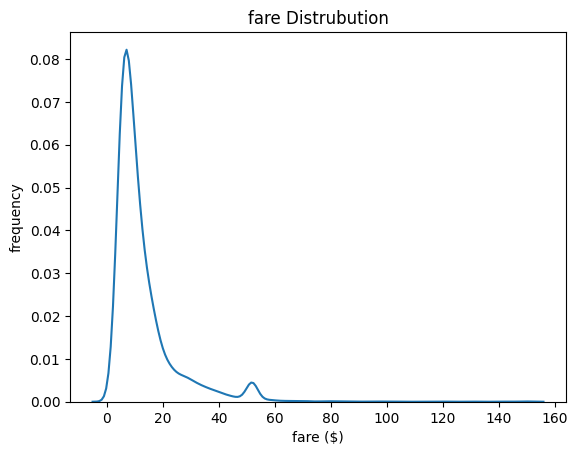

In [20]:
# kde plot - density
sns.kdeplot(data=df,x='fare')
plt.title('fare Distrubution')
plt.xlabel('fare ($)')
plt.ylabel('frequency')
plt.show()

### Observations from Fare Distribution Plots:

1.  **Right-Skewed Distribution**: Both the histogram and KDE plot clearly show that the fare distribution is heavily right-skewed. This indicates that most trips have lower fares, with a long tail extending towards higher fare values.
2.  **Concentration of Lower Fares**: A significant majority of rides fall within the lower fare ranges, likely corresponding to shorter distances or quicker trips.
3.  **Presence of Outliers/Higher Fares**: While most fares are low, there are a considerable number of trips with higher fares, as evidenced by the tail of the distribution. These could represent longer journeys or trips with special surcharges.
4.  **Mode around \$5-\$10**: The highest peak in the KDE plot and the most frequent bins in the histogram appear to be in the \$5 to \$10 range, suggesting this is the most common fare amount.
5.  **Variability**: The wide range of fares (from \$1 to \$150, as seen in `df.describe()`) is well-represented, showing considerable variability in trip costs.

## To do

- for others columns of countinous type :-

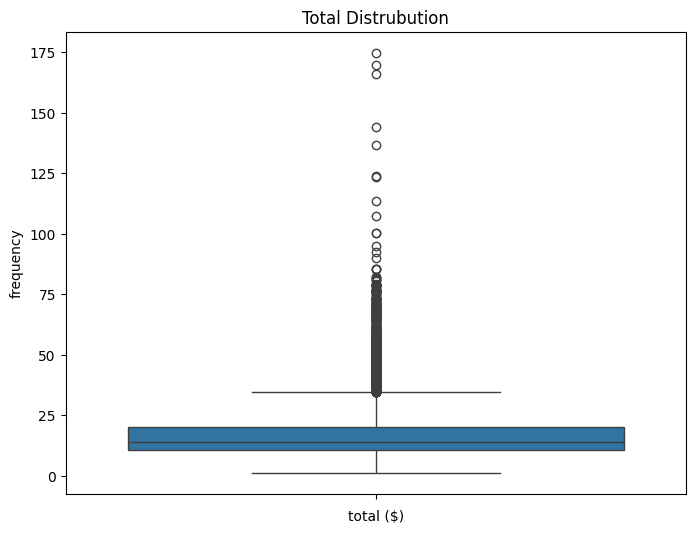

In [21]:
# Boxplot with clear annotations 'total'
plt.figure(figsize=(8,6))
sns.boxplot(data=df,y='total')
plt.title('Total Distrubution')
plt.xlabel('total ($)')
plt.ylabel('frequency')
plt.show()

In [22]:
# show stats for total
df.total.describe()

,total
count,6433.000000
mean,18.517794
std,13.815570
min,1.300000
25%,10.800000
50%,14.160000
75%,20.300000
max,174.820000


### Observations from `df.total.describe()`:

1.  **Count**: There are 6433 non-null entries, indicating a complete set of data for the 'total' column.
2.  **Mean**: The average total cost of a taxi ride is approximately \$18.52.
3.  **Standard Deviation**: With a standard deviation of about \$13.82, there is significant variability in the total costs, suggesting a wide range of trip prices.
4.  **Range**: Total costs range widely from a minimum of \$1.30 to a maximum of \$174.82.
5.  **Quartiles**:
    *   25% of trips cost \$10.80 or less.
    *   The median (50th percentile) total cost is \$14.16.
    *   75% of trips cost \$20.30 or less.
    *   The difference between the 75th and 25th percentile (Interquartile Range) is \$9.50, which provides a measure of the spread of the middle 50% of the data.
6.  **Outliers**: The maximum value of \$174.82 is considerably higher than the 75th percentile, suggesting the presence of high-cost outliers, which could correspond to very long trips or special circumstances. The boxplot visualization would further highlight these outliers.

## Payment method analysis

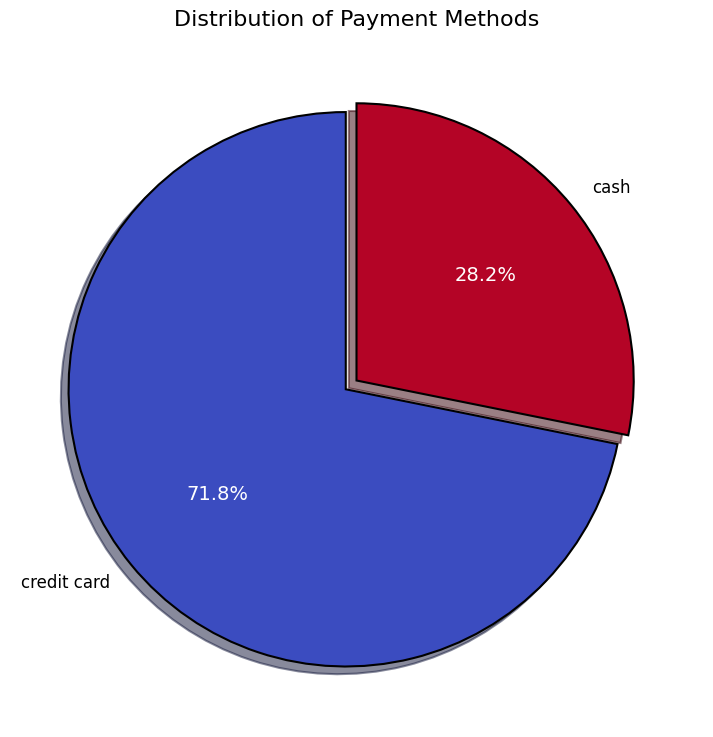

In [23]:
# pie charts - with counts cool colormap
payment_counts = df['payment'].value_counts()

# Define explode for the dominant slice (credit card)
explode = (0.05, 0) # Explode the first slice slightly

plt.figure(figsize=(9, 9)) # Slightly larger figure for better detail
wedges, texts, autotexts = plt.pie(payment_counts,
                                   labels=payment_counts.index,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=plt.cm.coolwarm(np.linspace(0, 1, len(payment_counts))),
                                   wedgeprops={'edgecolor': 'black', 'linewidth': 1.5, 'antialiased': True}, # Add edge for clarity
                                   explode=explode,
                                   shadow=True) # Add a shadow for a 3D effect

# Set font size for category labels
for text in texts:
    text.set_fontsize(12)
# Set font size and color for percentage labels
for autotext in autotexts:
    autotext.set_fontsize(14)
    autotext.set_color('white') # Make percentages stand out

plt.title('Distribution of Payment Methods', fontsize=16) # Larger title font
plt.ylabel('') # Hide y-label as it's a pie chart
plt.show()

### Observations from the Payment Method Pie Chart:

1.  **Credit Card Dominance:** Approximately **71.7%** of payments are made via credit card. This indicates a strong preference or prevalence of credit card usage among customers.
2.  **Cash Payments:** Cash accounts for the remaining **28.3%** of payments. While a minority, it still represents a substantial portion of transactions.

This distribution highlights the importance of accommodating credit card payments and suggests that a substantial portion of the customer base still prefers or uses cash. This insight is valuable for payment system optimization, understanding customer preferences, and financial forecasting.

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6433 non-null   object        
 10  pickup_zone      6433 non-null   object        
 11  dropoff_zone     6433 non-null   object        
 12  pickup_borough   6433 non-null   object        
 13  dropoff_borough  6433 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

## Time series plotting : for pickup and dropoff

In [29]:
import plotly.express as px

# pickup Analysis with interactive line plots for day wise analysis
# Extract date from pickup timestamp for daily analysis
df['pickup_date'] = df['pickup'].dt.date

# count pickup per day by grouping by pickup_date and taking the size of each group
daily_pickup_counts = df.groupby('pickup_date').size().reset_index(name='pickup_count')

# Create an interactive line plot using Plotly Express
fig = px.line(daily_pickup_counts, x='pickup_date', y='pickup_count',
              title='Daily Pickup Counts Over Time (Interactive)',
              labels={'pickup_date': 'Date', 'pickup_count': 'Number of Pickups'})

# Add hover data for better interactivity
fig.update_traces(mode='lines+markers', hoverinfo='x+y')

fig.show()

In [38]:
import plotly.express as px

df['trip_duration'] = df['dropoff'] - df['pickup']
df['trip_duration'] = df['trip_duration'].dt.total_seconds() / 60

fig = px.histogram(df, x='trip_duration', nbins=50, color='payment',
                   title='Trip Duration Distribution by Payment Method (Interactive)',
                   labels={'trip_duration': 'Trip Duration (minutes)', 'count': 'Frequency'})
fig.update_layout(bargap=0.1) # Add some gap between bars for better visualization
fig.show()

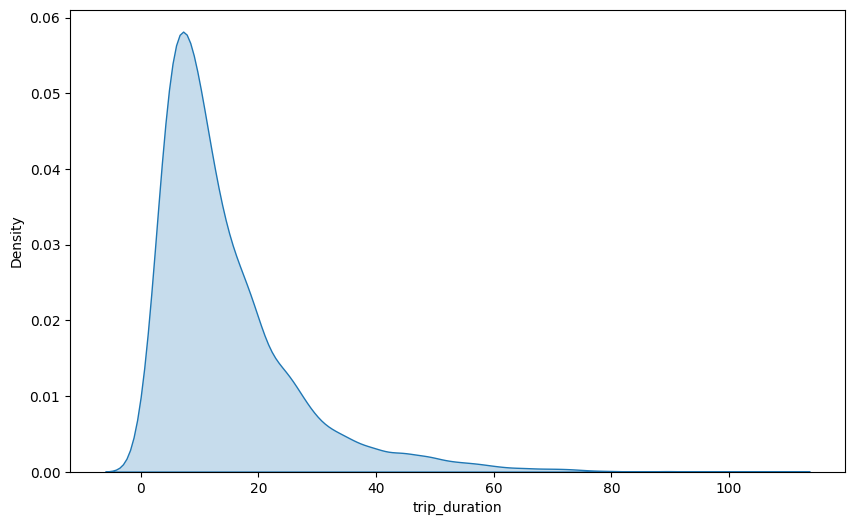

In [43]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='trip_duration', fill=True)

plt.show()

### Observations from Trip Duration Distribution by Pickup Borough:

1.  **Manhattan Dominance**: As expected, Manhattan (both pickup and dropoff) is the most frequent borough for taxi rides. The boxplot for Manhattan likely shows a wide range of trip durations, reflecting both short inter-Manhattan trips and longer journeys to other boroughs or airports.
2.  **Variability Across Boroughs**: There's a clear difference in the median trip durations and their spread across various pickup boroughs. Some boroughs might have predominantly shorter, more consistent trip durations (e.g., within a smaller borough), while others could show longer median durations and greater variability (e.g., a borough with a major airport).
3.  **Presence of Outliers**: All boroughs exhibit outliers, which represent exceptionally long taxi trips originating from those areas. The density and length of these outliers can vary, indicating specific long-distance routes or unusual traffic conditions.
4.  **Density of Trips**: Boroughs with higher trip volumes (like Manhattan) will naturally have more data points, making their boxplots richer in detail, while less frequent boroughs might have narrower boxes or fewer outliers. The median and interquartile range provide insight into the typical trip length for each borough.

In [46]:

print("Project Completed Successfully ✅")

Project Completed Successfully ✅
